In [ ]:
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit_ibm_runtime import Sampler
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from qiskit.visualization.timeline import draw


In [ ]:
#CRN = # wpisz swoje dane z IBM 
#TOKEN = # wpisz swoje dane z IBM

#service =QiskitRuntimeService(channel="ibm_cloud",instance=CRN, token=TOKEN)
#backend = service.backend("ibm_fez") #jest akurat wolne
backend = AerSimulator()

qiskit_runtime_service._discover_account:WARNING:2026-03-18 09:40:19,494: Loading account with the given token. A saved account will not be used.


## Task 1

Prepare circuits X , SX , SX →RZ (π/4) →SX , with measurement

In [3]:
Q = 1
q = 0

C = 1
c = 0

a = np.pi/4

N = 1000

In [4]:
# X gate
qc1 = QuantumCircuit(Q,C) #circuit with Q qubits and C cbits
qc1.x(q) 
qc1.measure(q,c)

In [5]:
#SX gate
qc2 = QuantumCircuit(Q,C) #circuit with Q qubits and C cbits
qc2.sx(q)
qc2.measure(q,c)

In [6]:
#SX - RZ (pi/4) - SX
qc3 = QuantumCircuit(Q,C) #circuit with Q qubits and C cbits
qc3.sx(q)
qc3.rz(a,q)
qc3.sx(q)
qc3.measure(q,c)

In [7]:
sampler = Sampler(backend) #prepare to run

In [8]:
job=sampler.run([qc1,qc2, qc3], shots=N) #run!

In [9]:
result=job.result() #read out

In [11]:
for j in range(len(result)):
    print(result[j].data.c.get_counts())

{'1': 969, '0': 31}
{'1': 495, '0': 505}
{'1': 818, '0': 182}


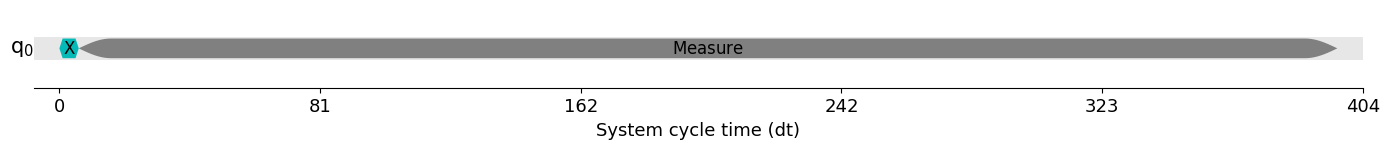

In [14]:
draw(qc1,target=backend.target,idle_wires=False)

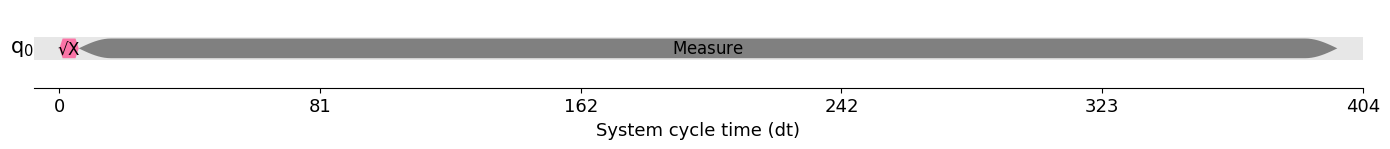

In [15]:
draw(qc2,target=backend.target,idle_wires=False)

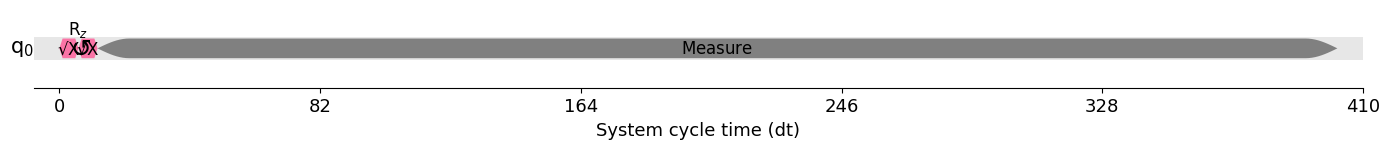

In [ ]:
draw(qc3,target=backend.target,idle_wires=False)

Wnioski: Pomiar zajmuje większość czasu. Jest bardzo powolny w stosunku do bramki.

## Task 2

Run circuit SX , SX , with two measurements

In [ ]:
Q = 1
q = 0

C2 = 2
c0 = 0
c1 = 1

N = 1000

In [17]:
# SX - SX
qc4 = QuantumCircuit(Q,C2) #circuit with Q qubits and C cbits
qc4.sx(q)
qc4.sx(q)
qc4.measure(q,c0)
qc4.measure(q,c1)

In [18]:
sampler = Sampler(backend)

In [19]:
job=sampler.run([qc4], shots=N)

In [20]:
result=job.result()

In [22]:
for i in range(len(result)):
    print(result[i].data.c.get_counts())

{'11': 945, '01': 48, '00': 7}


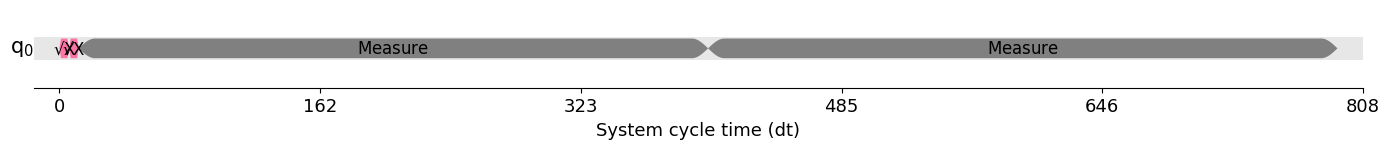

In [23]:
draw(qc4,target=backend.target,idle_wires=False)

## Task 3

Run circuit SX , measurement, again SX , next measurement

In [64]:
Q = 1
q = 0

C2 = 2
c0 = 0
c1 = 1

N = 1000

In [65]:
#SX gate
qc5 = QuantumCircuit(Q,C2) #circuit with Q qubits and C cbits
qc5.sx(q)
qc5.measure(q,c0)
qc5.sx(q)
qc5.measure(q,c1)

In [66]:
sampler = Sampler(backend)

In [67]:
job=sampler.run([qc5], shots=N)

In [68]:
result=job.result()

In [69]:
for i in range(len(result)):
    print(result[i].data.c.get_counts())

{'11': 269, '00': 227, '01': 260, '10': 244}


order of outcomes”BA” : A – result of cbit 0, B – result of cbit 1 (right to left)

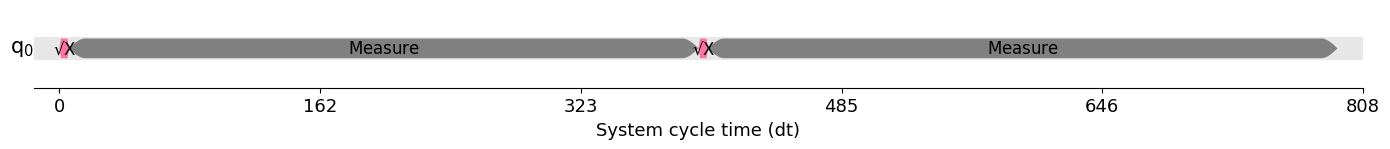

In [71]:
draw(qc5,target=backend.target,idle_wires=False)

## Task 4

Run conditional circuit: 
SX then measurement, if 0 again SX ,if 1 do X , finally SX again and measurement

In [73]:
Q = 1
q = 0

C2 = 2
c0 = 0
c1 = 1

N = 1000
value = 0

In [86]:
#conditional gate

qc6 = QuantumCircuit(Q,C2) #circuit with Q qubits and C cbits
qc6.sx(q)
qc6.measure(q,c0)

with qc6.if_test((c,value)) as other:
    if c == value:
        qc6.sx(q)
with other:
    qc6.x(q)
    
qc6.sx(q)
qc6.measure(q,c1)

In [87]:
sampler = Sampler(backend)

In [88]:
job=sampler.run([qc6], shots=N)

In [89]:
result=job.result()

In [90]:
for i in range(len(result)):
    print(result[i].data.c.get_counts())

{'01': 246, '10': 477, '11': 269, '00': 8}


Komputer kwantowy nie jest idealny!

In [92]:
#draw(qc6,target=backend.target,idle_wires=False)

Nie umiemy jeszcze tego implementować